# Titanic 生存数据分析报告

**数据集**：Titanic（Kaggle 经典公开数据集，891 名乘客，12 个字段）

**分析目标（5 项）**：
1. 缺失值统计：各列缺失数量与比例
2. 分布直方图：关键数值列的分布
3. 相关性热力图：数值列间的相关系数
4. 分组聚合：`groupby` 与 `pivot_table` 做聚合统计
5. 讲故事的图：一张能清晰传达洞察的可视化

**技术栈**：`pandas`（读取/聚合）、`matplotlib` + `seaborn`（绘图）。
涉及基础操作：`read_csv`、`groupby`、`merge`、`pivot_table`。

## 0. 导入库并读取数据

使用 `pandas.read_csv` 载入 CSV，并快速预览数据结构与数值概览。

In [1]:
# ---- 导入常用库 ----
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# read_csv：从本地 CSV 读取为 DataFrame（这是 pandas 最基础的读取操作）
df = pd.read_csv('data/titanic.csv')

# 整体规模与数值概览：shape 看行/列，describe 看数值列统计
print(f'数据形状: {df.shape}')
print(f'整体生存率: {df["Survived"].mean():.3f}')
display(df.head())
display(df.describe().round(2))

数据形状: (891, 12)
整体生存率: 0.384


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


## 1. 缺失值统计

统计每一列的缺失值**数量**与**比例**，定位需要清洗或谨慎使用的字段。

In [2]:
# isnull().sum() 统计每列缺失数量；除以总行数得到缺失比例
missing_count = df.isnull().sum()
missing_ratio = missing_count / len(df)

# 合并为一张整洁的汇总表（只用基础操作，不引入新依赖）
missing_tbl = pd.DataFrame({
    'missing_count': missing_count,
    'missing_ratio': missing_ratio.round(4),
}).sort_values('missing_count', ascending=False)

print('=== 缺失值统计 ===')
missing_tbl

=== 缺失值统计 ===


,missing_count,missing_ratio
Cabin,687,0.7710
Age,177,0.1987
Embarked,2,0.0022
PassengerId,0,0.0000
Name,0,0.0000
Pclass,0,0.0000
Survived,0,0.0000
Sex,0,0.0000
Parch,0,0.0000
SibSp,0,0.0000


## 2. 分布直方图

对关键数值列（`Age`、`Fare`、`SibSp`、`Parch`）绘制分布直方图，直观感受乘客年龄、票价与同行亲属数量的分布形态。

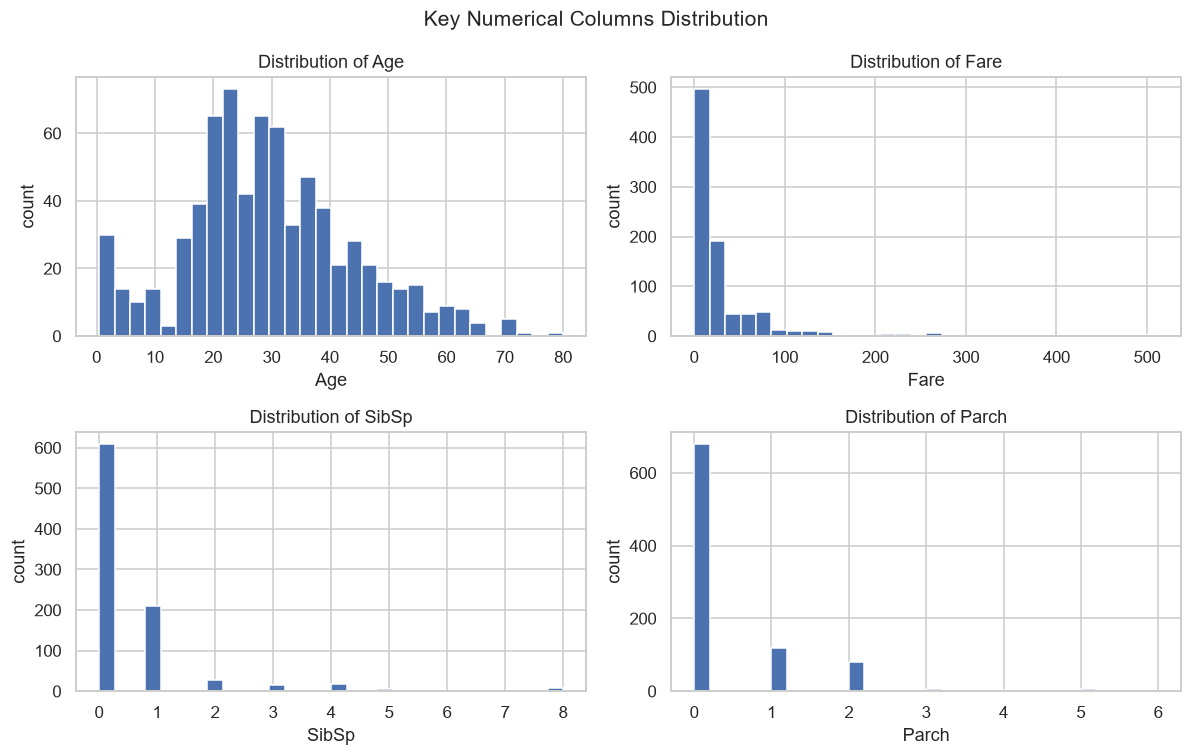

In [3]:
# 用 2x2 子图一次性展示四个数值列的分布
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), num_cols):
    # dropna 避免 NaN 干扰直方图计数
    ax.hist(df[col].dropna(), bins=30, color='#4C72B0', edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('count')
fig.suptitle('Key Numerical Columns Distribution', fontsize=14)
fig.tight_layout()
plt.show()

## 3. 相关性热力图

对数值列计算 Pearson 相关系数矩阵，并用 `seaborn.heatmap` 可视化，快速发现哪些变量彼此相关（例如 `Fare` 与 `Pclass` 负相关）。

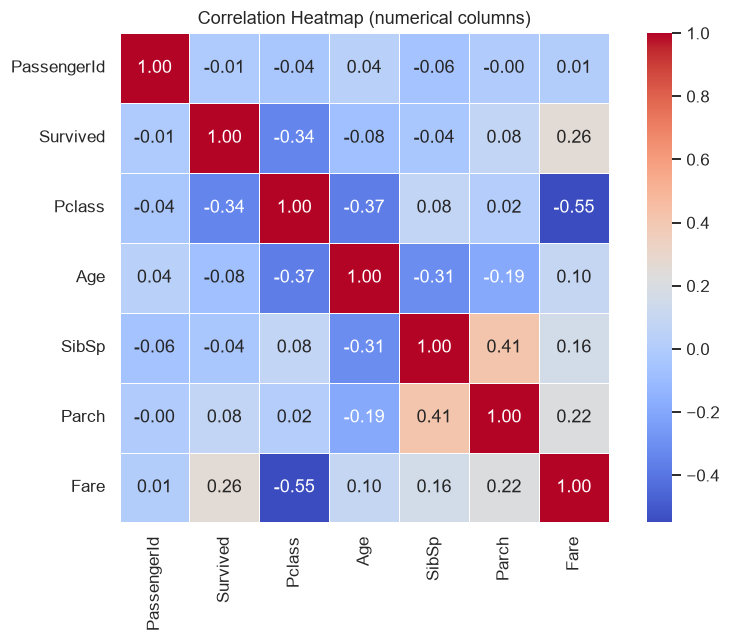

In [4]:
# corr：仅对数值列计算相关系数（numeric_only 过滤掉文本列）
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=.5, ax=ax)
ax.set_title('Correlation Heatmap (numerical columns)')
plt.tight_layout()
plt.show()

## 4. 分组聚合

- 用 `merge` 把 `Pclass` 代码（1/2/3）映射为可读性更好的类名；
- 用 `groupby` 按 `Pclass` / `Sex` 做聚合统计；
- 用 `pivot_table` 生成「性别 × 舱位」的生存率矩阵。

In [5]:
# merge：把舱位代码映射为类名（演示 merge 基础操作，how='left' 保留原表）
class_map = pd.DataFrame({
    'Pclass': [1, 2, 3],
    'ClassName': ['First', 'Second', 'Third'],
})
df = df.merge(class_map, on='Pclass', how='left')

# groupby ①：按舱位聚合（平均票价、平均年龄、生存率、人数）
by_class = df.groupby('ClassName').agg(
    avg_fare=('Fare', 'mean'),
    avg_age=('Age', 'mean'),
    survival_rate=('Survived', 'mean'),
    n=('Survived', 'size'),
).round(3)
print('=== 按舱位分组聚合 ===')
display(by_class)

# groupby ②：按性别看整体生存率（与舱位结果互为补充）
by_sex = df.groupby('Sex')['Survived'].agg(['mean', 'size']).round(3)
print('=== 按性别分组聚合 ===')
display(by_sex)

# groupby ③：先按年龄分箱（pd.cut），再 groupby 看各年龄段生存率
df['AgeBand'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Adult', 'Senior', 'Elder'],
)
by_age = df.groupby('AgeBand', observed=True)['Survived'].agg(['mean', 'size']).round(3)
print('=== 按年龄段分组聚合 ===')
display(by_age)

# groupby ④：按登船港口（Embarked）看生存率
by_embark = df.groupby('Embarked')['Survived'].agg(['mean', 'size']).round(3)
print('=== 按登船港口分组聚合 ===')
display(by_embark)

# pivot_table：行=性别，列=舱位，值=生存率，得到交叉汇总矩阵
surv_pivot = pd.pivot_table(
    df, index='Sex', columns='ClassName',
    values='Survived', aggfunc='mean',
).round(3)
print('=== 性别 × 舱位 生存率矩阵 ===')
surv_pivot

=== 按舱位分组聚合 ===


,avg_fare,avg_age,survival_rate,n
ClassName,,,,
First,84.155,38.233,0.630,216
Second,20.662,29.878,0.473,184
Third,13.676,25.141,0.242,491


=== 按性别分组聚合 ===


,mean,size
Sex,,
female,0.742,314
male,0.189,577


=== 按年龄段分组聚合 ===


,mean,size
AgeBand,,
Child,0.580,69
Teen,0.429,70
Adult,0.383,358
Senior,0.400,195
Elder,0.227,22


=== 按登船港口分组聚合 ===


,mean,size
Embarked,,
C,0.554,168
Q,0.390,77
S,0.337,644


=== 性别 × 舱位 生存率矩阵 ===


ClassName,First,Second,Third
Sex,,,
female,0.968,0.921,0.500
male,0.369,0.157,0.135


## 5. 讲故事的图：谁更可能活下来？

把上面的 `pivot_table` 直接画成「分组柱状图」：x 轴为性别，颜色区分舱位，y 轴是生存率。

**洞察**：无论哪个舱位，女性生存率都显著高于男性；且头等舱生存率整体最高——这正是 Titanic 事件中「妇女与儿童优先（尤其一等舱）」历史的量化体现。

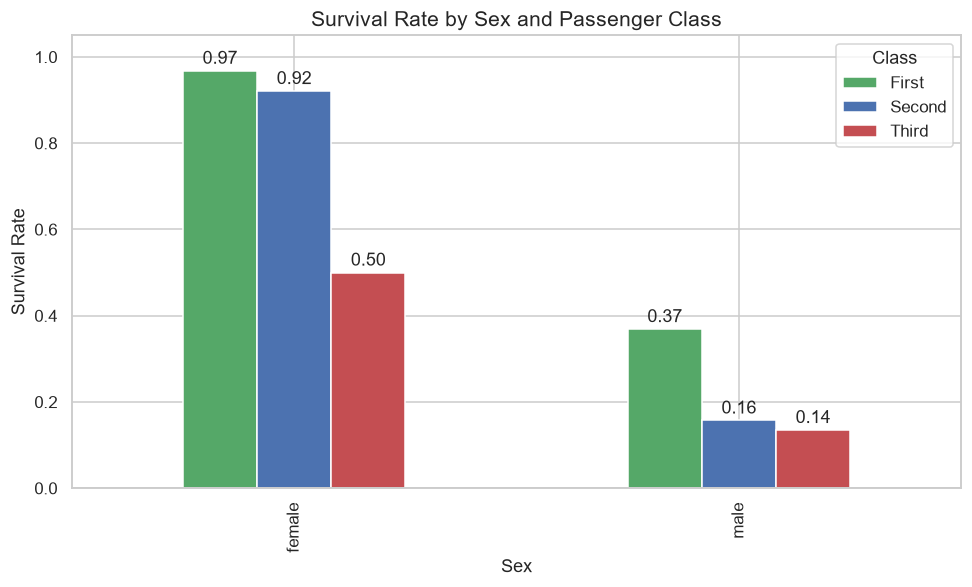

In [6]:
# 用 pivot_table 的结果绘图，让数据自己讲故事
fig, ax = plt.subplots(figsize=(9, 5.5))
surv_pivot.plot(kind='bar', ax=ax, color=['#55A868', '#4C72B0', '#C44E52'])
ax.set_title('Survival Rate by Sex and Passenger Class', fontsize=14)
ax.set_xlabel('Sex')
ax.set_ylabel('Survival Rate')
ax.set_ylim(0, 1.05)
ax.legend(title='Class')

# 在柱顶标注具体数值，便于阅读（bar_label 是 matplotlib 新版本特性）
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=2)
plt.tight_layout()
plt.show()

## 结论小结

- **缺失值**：`Cabin` 缺失最严重（约 77%），`Age` 约 20% 缺失，建模时需处理；`Embarked` 仅 2 条缺失可简单填充。
- **分布**：票价 `Fare` 右偏严重（多数人低票价，少数极高），`Age` 集中在 20–40 岁。
- **相关性**：`Fare` 与 `Survived` 正相关、`Pclass` 与 `Survived` 负相关——有钱/高舱位更易幸存。
- **分组聚合**：头等舱生存率最高；女性生存率是男性的数倍。
- **故事图**：性别 + 舱位共同决定了生存机会，一等舱女性生存率接近 0.97。

> 进阶方向：用 `fillna` 处理 `Age`/`Embarked`、对 `Fare` 做 log 变换、用 `sklearn` 训练一个生存预测模型。